In [36]:
import pandas as pd
import matplotlib.pyplot as plt

df_price = pd.read_csv("../data/processed/cleaned_eth_price.csv")
df_post = pd.read_csv("../data/processed/cleaned_eth_post.csv")



In [43]:
print(df_post['score'].max())
print(df_post['score'].min())
print(df_post.head())

2507
-314
                     Unnamed: 0.1  Unnamed: 0 subreddit  \
created_utc                                               
2020-01-19 04:42:48             0           0  ethereum   
2020-01-19 04:41:00             1           1  ethereum   
2020-01-19 04:37:31             2           2  ethereum   
2020-01-19 04:37:10             3           3  ethereum   
2020-01-19 04:26:30             4           4  ethereum   

                                                                  body  score  \
created_utc                                                                     
2020-01-19 04:42:48    yeah that s infallible logic you re using there      6   
2020-01-19 04:41:00                                 remindme  6 months      3   
2020-01-19 04:37:31    thats what people said here about 2018 and 2019     -5   
2020-01-19 04:37:10  my comment is 100  accurate    according to th...    -13   
2020-01-19 04:26:30  risk of a smart contract being hacked  if ther...      2   

        

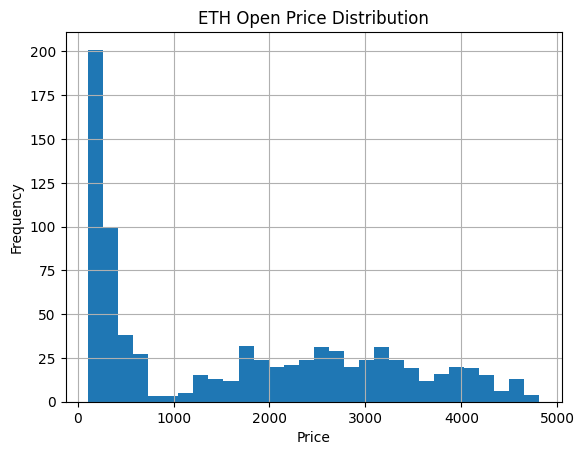

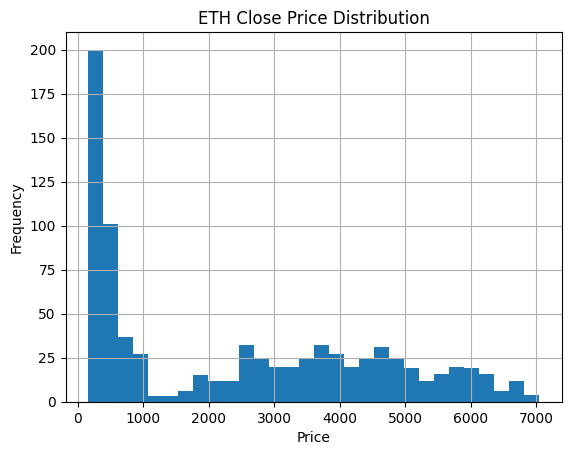

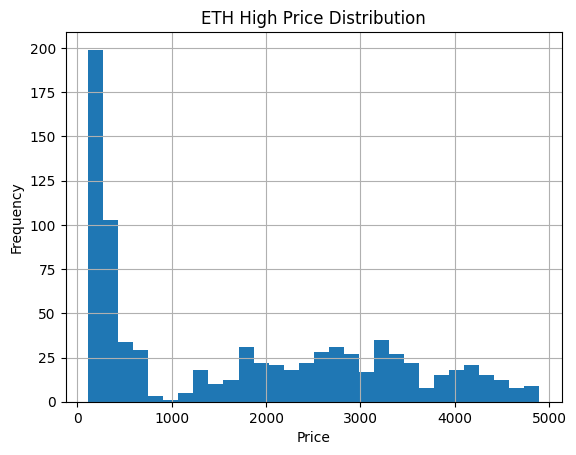

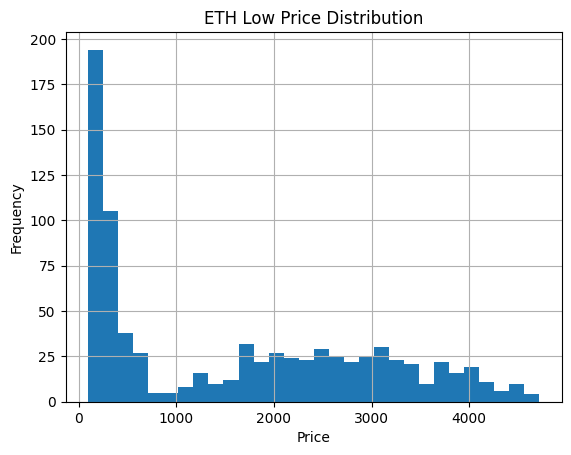

In [38]:
# Histo Analysis of df_price
df_price['Open'].astype(float).hist(bins=30)
plt.title('ETH Open Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

df_price['Close'].astype(float).hist(bins=30)
plt.title('ETH Close Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

df_price['High'].astype(float).hist(bins=30)
plt.title('ETH High Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

df_price['Low'].astype(float).hist(bins=30)
plt.title('ETH Low Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()




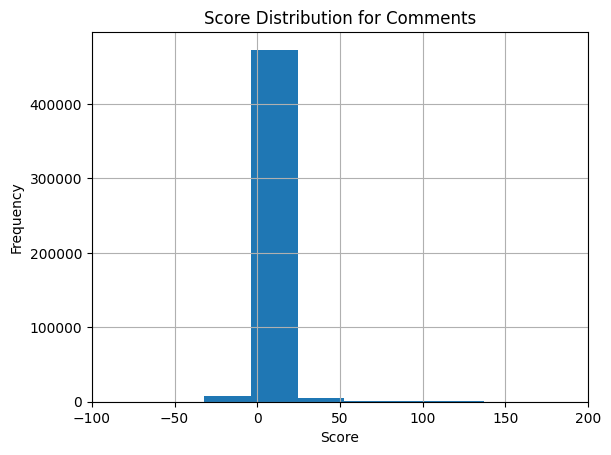

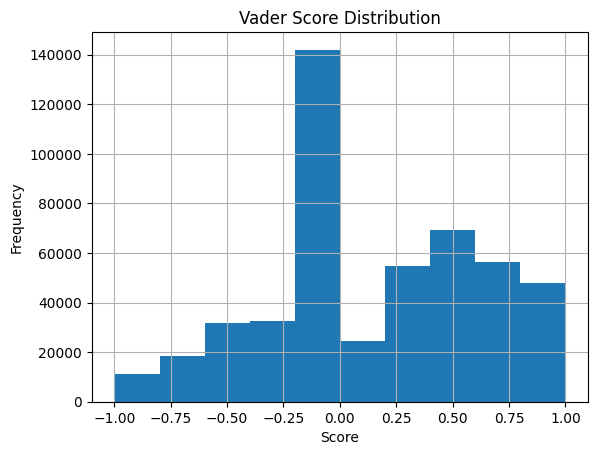

In [39]:
# Histo Analysis of df_post

df_post["score"].hist(bins=100)
plt.title("Score Distribution for Comments")
plt.xlabel("Score")
plt.xlim(-100, 200)
plt.ylabel("Frequency")
plt.show()

# Most score in range ~-10 to 25

df_post["vader_scores"].hist(bins=10)
plt.title("Vader Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()


Sample positive posts:
created_utc
2020-01-19 03:44:28    with 32 eth you can be a  staker  in the new e...
2020-01-19 03:19:28    but at the same time  don t cry about the rich...
2020-01-19 02:25:51    gt  whether or not the communities want it is ...
2020-01-19 02:09:56    if you have under 32 you have no option but to...
2020-01-19 00:44:06                           that s good advice  thanks
Name: body, dtype: object
Sample negative posts:
created_utc
2020-01-19 02:23:30    the first phase of eth2 goes live this year   ...
2020-01-19 02:16:52                                         no one cares
2020-01-19 00:48:36    there are no staking rewards in ethereum  try ...
2020-01-18 23:47:32    this is such a deceptive video thumbnail  i ju...
2020-01-18 23:20:33                      and craig wright is just stupid
Name: body, dtype: object


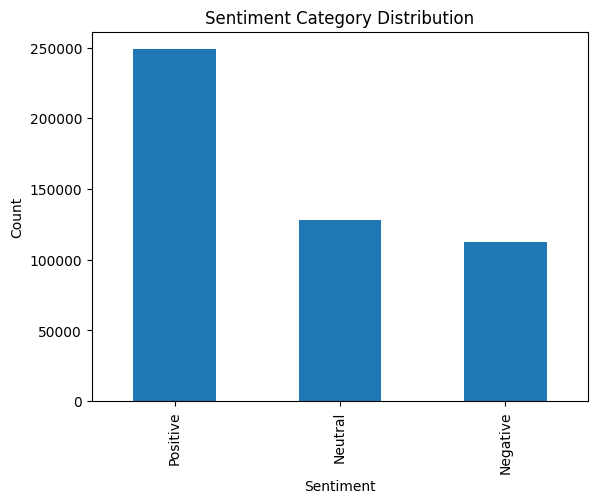

In [41]:
# Compare posts with highly positive and highly negative scores
positive_posts = df_post[df_post['vader_scores'] > 0.5]
negative_posts = df_post[df_post['vader_scores'] < -0.5]
print('Sample positive posts:')
print(positive_posts['body'].head())
print('Sample negative posts:')
print(negative_posts['body'].head())

# Group and visualize sentiment categories
def categorize_sentiment(score):
    if score > 0.05:
        return 'Positive'
    elif score < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df_post['sentiment_category'] = df_post['vader_scores'].apply(categorize_sentiment)
sentiment_counts = df_post['sentiment_category'].value_counts()
sentiment_counts.plot(kind='bar')
plt.title('Sentiment Category Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()


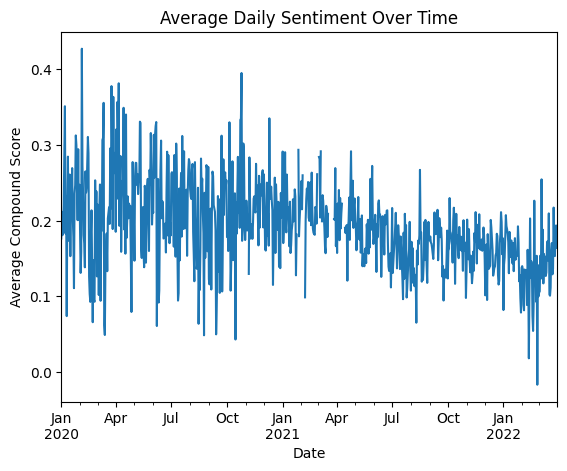

In [47]:
df_post['created_utc'] = pd.to_datetime(df_post['created_utc'], unit='s')
df_post.set_index('created_utc', inplace=True)
df_post.resample('D')['vader_scores'].mean().plot()
plt.title('Average Daily Sentiment Over Time')
plt.xlabel('Date')
plt.ylabel('Average Compound Score')
plt.show()

In [46]:
# Reset index 
df_post.reset_index(inplace=True)

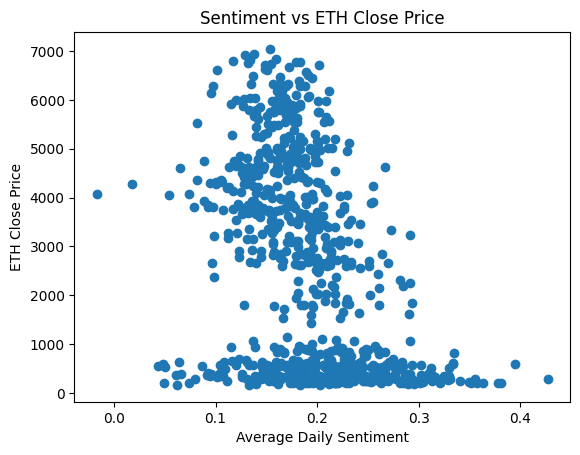

In [ ]:
#  Correlate sentiment with ETH price
df_post['date'] = df_post.index.date
daily_sentiment = df_post.groupby('date')['vader_scores'].mean().reset_index()
df_price['Date'] = pd.to_datetime(df_price['Date']).dt.date
merged = pd.merge(daily_sentiment, df_price, left_on='date', right_on='Date')
plt.scatter(merged['vader_scores'], merged['Close'].astype(float))
plt.title('Sentiment vs ETH Close Price')
plt.xlabel('Average Daily Sentiment')
plt.ylabel('ETH Close Price')
plt.show()

Correlation between average daily sentiment and ETH close price: -0.4135


C:\Users\jktra\AppData\Local\Temp\ipykernel_67392\2574990183.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_price_by_bin = merged.groupby('sentiment_bin')['Close'].mean()


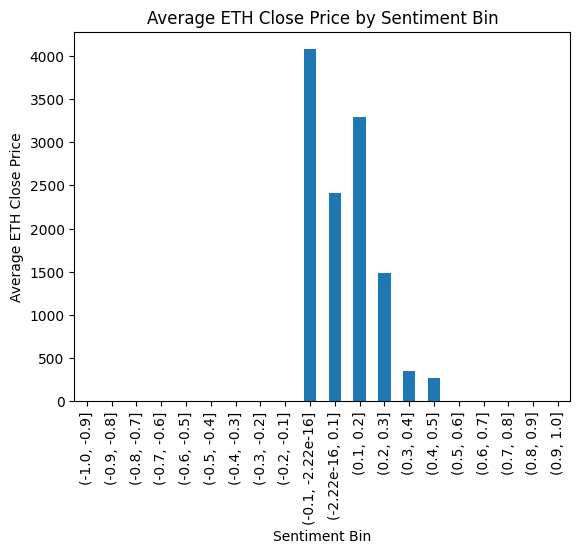

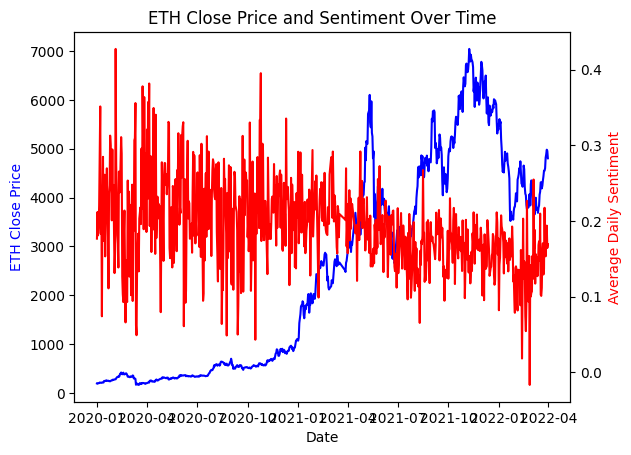

In [ ]:
# Calculate correlation coefficient between sentiment and ETH close price
correlation = merged['vader_scores'].corr(merged['Close'].astype(float))
print(f'Correlation between average daily sentiment and ETH close price: {correlation:.4f}')

# Group sentiment into bins and plot average ETH price for each bin
import numpy as np
merged['sentiment_bin'] = pd.cut(merged['vader_scores'], bins=np.arange(-1, 1.1, 0.1))
avg_price_by_bin = merged.groupby('sentiment_bin')['Close'].mean()
avg_price_by_bin.plot(kind='bar')
plt.title('Average ETH Close Price by Sentiment Bin')
plt.xlabel('Sentiment Bin')
plt.ylabel('Average ETH Close Price')
plt.show()

# Overlay ETH price and sentiment trends over time
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(merged['date'], merged['Close'], color='blue', label='ETH Close Price')
ax1.set_xlabel('Date')
ax1.set_ylabel('ETH Close Price', color='blue')
ax2 = ax1.twinx()
ax2.plot(merged['date'], merged['vader_scores'], color='red', label='Average Daily Sentiment')
ax2.set_ylabel('Average Daily Sentiment', color='red')
plt.title('ETH Close Price and Sentiment Over Time')
plt.show()